<h1 style="color:magenta;">Exploración Inicial del Dataset 05 N-CMAPSS</h1>
<p> Valentina Arce España <p>
<p> Febrero 10, 2026 <p>
<p> Este set se enfoca en fallas de eficiencia y flujo del compresor de alta presión.<p>

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ruta al archivo (asegúrate de que el nombre sea el correcto para el DS05)
file_path = 'N-CMAPSS_DS05.h5'

# 1. Abrir el archivo en modo lectura ('r')
with h5py.File(file_path, 'r') as hdf:
    # Listar todas las llaves principales para ver qué hay dentro
    print("Llaves principales en el archivo HDF5:")
    print(list(hdf.keys()))

Llaves principales en el archivo HDF5:
['A_dev', 'A_test', 'A_var', 'T_dev', 'T_test', 'T_var', 'W_dev', 'W_test', 'W_var', 'X_s_dev', 'X_s_test', 'X_s_var', 'X_v_dev', 'X_v_test', 'X_v_var', 'Y_dev', 'Y_test']


In [2]:
with h5py.File(file_path, 'r') as hdf:
    # Cargar nombres de variables (decodificamos de bytes a strings para leerlos bien)
    w_cols = np.array(hdf.get('W_var')).astype(str)   # Condiciones Operativas
    x_s_cols = np.array(hdf.get('X_s_var')).astype(str) # Sensores Físicos
    x_v_cols = np.array(hdf.get('X_v_var')).astype(str) # Sensores Virtuales
    t_cols = np.array(hdf.get('T_var')).astype(str)   # Theta (Salud del motor)
    a_cols = np.array(hdf.get('A_var')).astype(str)   # Información Auxiliar

    print("Columnas W (Operativas):", w_cols)
    print("Columnas X_s (Sensores):", x_s_cols)
    print("Columnas T (Theta/Salud):", t_cols)
    print("Columnas A (Auxiliares):", a_cols)

Columnas W (Operativas): ['alt' 'Mach' 'TRA' 'T2']
Columnas X_s (Sensores): ['T24' 'T30' 'T48' 'T50' 'P15' 'P2' 'P21' 'P24' 'Ps30' 'P40' 'P50' 'Nf'
 'Nc' 'Wf']
Columnas T (Theta/Salud): ['fan_eff_mod' 'fan_flow_mod' 'LPC_eff_mod' 'LPC_flow_mod' 'HPC_eff_mod'
 'HPC_flow_mod' 'HPT_eff_mod' 'HPT_flow_mod' 'LPT_eff_mod' 'LPT_flow_mod']
Columnas A (Auxiliares): ['unit' 'cycle' 'Fc' 'hs']


In [3]:
with h5py.File(file_path, 'r') as hdf:
    # Cargamos A_dev (Auxiliary data del set de desarrollo)
    A_dev = np.array(hdf.get('A_dev'))

# Crear DataFrame de Pandas para verlo bonito
df_A = pd.DataFrame(A_dev, columns=a_cols)

print("Primeras 5 filas de Información Auxiliar:")
print(df_A.head())

print("\nEstadísticas (mira los IDs de unidad y ciclos):")
print(df_A.describe())

Primeras 5 filas de Información Auxiliar:
   unit  cycle   Fc   hs
0   1.0    1.0  2.0  1.0
1   1.0    1.0  2.0  1.0
2   1.0    1.0  2.0  1.0
3   1.0    1.0  2.0  1.0
4   1.0    1.0  2.0  1.0

Estadísticas (mira los IDs de unidad y ciclos):
               unit         cycle            Fc            hs
count  4.350606e+06  4.350606e+06  4.350606e+06  4.350606e+06
mean   3.372042e+00  4.017756e+01  2.290199e+00  2.852072e-01
std    1.826816e+00  2.383124e+01  7.851996e-01  4.515131e-01
min    1.000000e+00  1.000000e+00  1.000000e+00  0.000000e+00
25%    2.000000e+00  2.000000e+01  2.000000e+00  0.000000e+00
50%    3.000000e+00  4.000000e+01  2.000000e+00  0.000000e+00
75%    5.000000e+00  5.900000e+01  3.000000e+00  1.000000e+00
max    6.000000e+00  1.000000e+02  3.000000e+00  1.000000e+00


In [4]:
# Agrupar por 'unit' y contar el máximo de 'cycle'
vida_util = df_A.groupby('unit')['cycle'].max()

print("Vida útil (ciclos totales) por cada motor en el set de desarrollo:")
print(vida_util)

# Ver qué unidades tenemos disponibles
print("\nIDs de las Unidades disponibles:", df_A['unit'].unique())

Vida útil (ciclos totales) por cada motor en el set de desarrollo:
unit
1.0     80.0
2.0     80.0
3.0     65.0
4.0     99.0
5.0    100.0
6.0     67.0
Name: cycle, dtype: float64

IDs de las Unidades disponibles: [1. 2. 3. 4. 5. 6.]


In [5]:
with h5py.File(file_path, 'r') as hdf:
    # Cargar datos numéricos
    W_dev = np.array(hdf.get('W_dev'))
    X_s_dev = np.array(hdf.get('X_s_dev'))

# Crear DataFrames
df_W = pd.DataFrame(W_dev, columns=w_cols)
df_X_s = pd.DataFrame(X_s_dev, columns=x_s_cols)

# Añadir la columna de unidad para saber a quién pertenece cada fila
df_W['unit'] = df_A['unit']
df_X_s['unit'] = df_A['unit']

print("Condiciones Operativas (W) - Ejemplo:")
print(df_W.head())

print("\nLecturas de Sensores (X_s) - Ejemplo:")
print(df_X_s.head())

Condiciones Operativas (W) - Ejemplo:
      alt      Mach        TRA          T2  unit
0  3002.0  0.370377  81.122467  521.900827   1.0
1  3010.0  0.370818  81.122467  521.904702   1.0
2  3017.0  0.371259  81.122467  521.912580   1.0
3  3030.0  0.372078  81.122467  521.926210   1.0
4  3038.0  0.372519  81.122467  521.930527   1.0

Lecturas de Sensores (X_s) - Ejemplo:
          T24          T30          T48          T50        P15         P2  \
0  628.067440  1511.513103  1926.925730  1305.942703  20.030712  14.445617   
1  628.055445  1511.458504  1926.939420  1305.955847  20.028054  14.444604   
2  628.062671  1511.447754  1926.891685  1305.888172  20.027157  14.444141   
3  628.074735  1511.440602  1926.851322  1305.806355  20.025641  14.443352   
4  628.077782  1511.400057  1926.753906  1305.700646  20.023867  14.442366   

         P21        P24        Ps30         P40        P50           Nf  \
0  20.335749  25.654299  433.588452  440.331422  16.506868  2240.817081   
1  20.3330

In [6]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Extraemos los nombres de las columnas (vienen como bytes)
    sensor_names = np.array(hdf.get('X_s_var')).astype(str) 
    
    # 2. Extraemos los datos crudos
    raw_sensors = np.array(hdf.get('X_s_dev'))

# 3. Al crear el DataFrame de Pandas, le pasamos los nombres que extrajimos
df_sensors = pd.DataFrame(data=raw_sensors, columns=sensor_names)

print("Orden oficial de los sensores en DS01:")
print(sensor_names)

Orden oficial de los sensores en DS01:
['T24' 'T30' 'T48' 'T50' 'P15' 'P2' 'P21' 'P24' 'Ps30' 'P40' 'P50' 'Nf'
 'Nc' 'Wf']


In [7]:
with h5py.File(file_path, 'r') as hdf:
    T_dev = np.array(hdf.get('T_dev'))

df_T = pd.DataFrame(T_dev, columns=t_cols)
df_T['unit'] = df_A['unit']

print("Parámetros de Salud (Theta) - Ejemplo:")
print(df_T.head())

Parámetros de Salud (Theta) - Ejemplo:
   fan_eff_mod  fan_flow_mod  LPC_eff_mod  LPC_flow_mod  HPC_eff_mod  \
0          0.0           0.0          0.0           0.0    -0.000261   
1          0.0           0.0          0.0           0.0    -0.000261   
2          0.0           0.0          0.0           0.0    -0.000261   
3          0.0           0.0          0.0           0.0    -0.000261   
4          0.0           0.0          0.0           0.0    -0.000261   

   HPC_flow_mod  HPT_eff_mod  HPT_flow_mod  LPT_eff_mod  LPT_flow_mod  unit  
0     -0.000613          0.0           0.0          0.0           0.0   1.0  
1     -0.000613          0.0           0.0          0.0           0.0   1.0  
2     -0.000613          0.0           0.0          0.0           0.0   1.0  
3     -0.000613          0.0           0.0          0.0           0.0   1.0  
4     -0.000613          0.0           0.0          0.0           0.0   1.0  


<div class="alert alert-block alert-info">
Cómo se describió en el dataset, el HPC_eff_mod y HPC_flow_mod son las únicas columnas con valor porque solo el HPC presenta falla.

<h2 style="color:magenta;">Visualizaciones Iniciales: Motor 1 - Flight Class 2</h2>

El sensor T50 está en el índice: 3


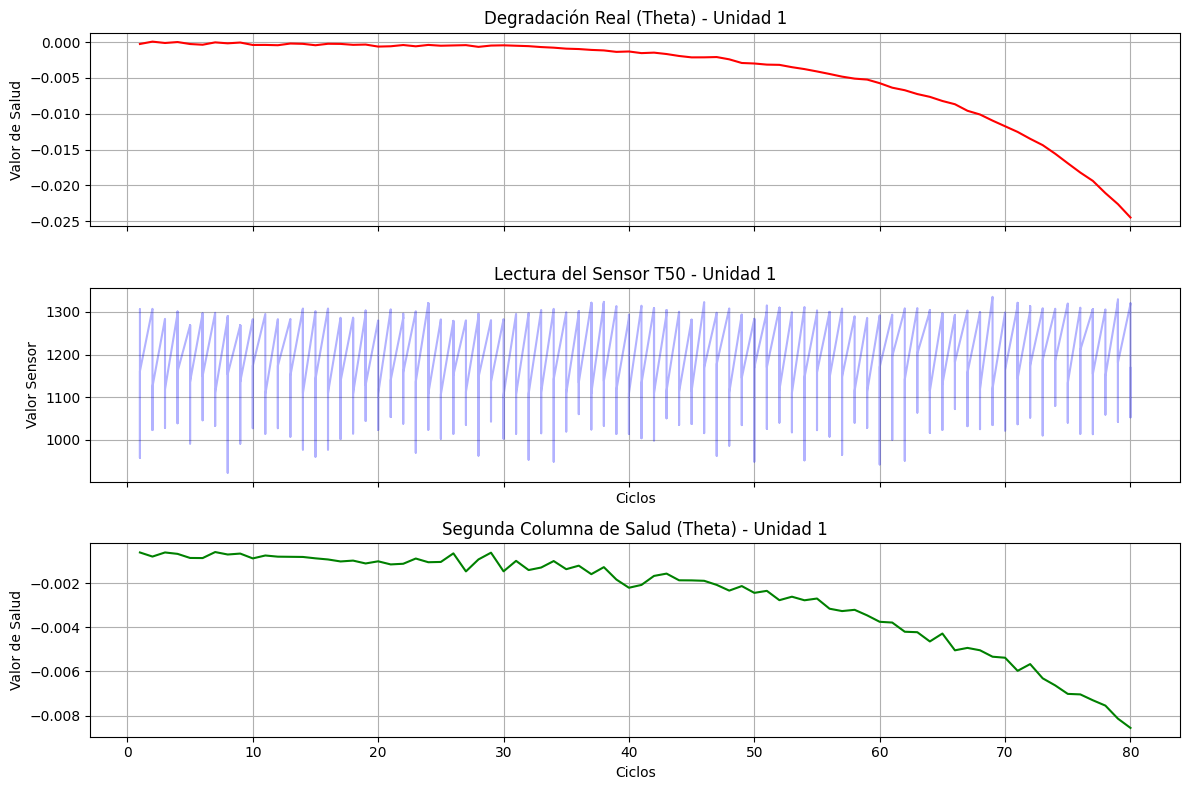

In [8]:
import matplotlib.pyplot as plt
unit_id = 1

with h5py.File(file_path, 'r') as hdf:
    # 1. Primero, leemos los nombres de los sensores para encontrar el índice correcto
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Buscamos en qué posición está 'T50'
    # Esto evita el IndexError porque busca dinámicamente
    try:
        t50_index = np.where(sensor_names == 'T50')[0][0]
        print(f"El sensor T50 está en el índice: {t50_index}")
    except IndexError:
        print("El sensor T50 no se encontró. Los sensores disponibles son:", sensor_names)
        # Si no está T50, podrías elegir otro como 'T24' o el último disponible
        t50_index = 0 

    # 2. Extraer datos de la Unidad 1 con la máscara
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    
    cycles = A_dev[mask, 1]
    
    # Extraer Theta (Salud) - En DS01 suele haber solo 2 (HPT y LPT) o incluso 1
    # Vamos a extraer la primera columna de salud disponible
    theta_data = hdf.get('T_dev')[mask, 4]
    theta_data_2 = hdf.get('T_dev')[mask, 5] 

    # Extraer el sensor usando el índice que encontramos arriba
    sensor_data = hdf.get('X_s_dev')[mask, t50_index]

# 3. Graficar
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax1.plot(cycles, theta_data, color='red')
ax1.set_title(f'Degradación Real (Theta) - Unidad {unit_id}')
ax1.set_ylabel('Valor de Salud')
ax1.grid(True)

ax2.plot(cycles, sensor_data, color='blue', alpha=0.3) # Alpha para ver mejor la densidad
ax2.set_title(f'Lectura del Sensor {sensor_names[t50_index]} - Unidad {unit_id}')
ax2.set_ylabel('Valor Sensor')
ax2.set_xlabel('Ciclos')
ax2.grid(True)

ax3.plot(cycles, theta_data_2, color='green')
ax3.set_title(f'Segunda Columna de Salud (Theta) - Unidad {unit_id}')
ax3.set_ylabel('Valor de Salud')
ax3.set_xlabel('Ciclos')
ax3.grid(True)

plt.tight_layout()
plt.show()

Sensores a graficar: ['T24', 'T30', 'T50', 'Wf', 'Nf', 'Nc']


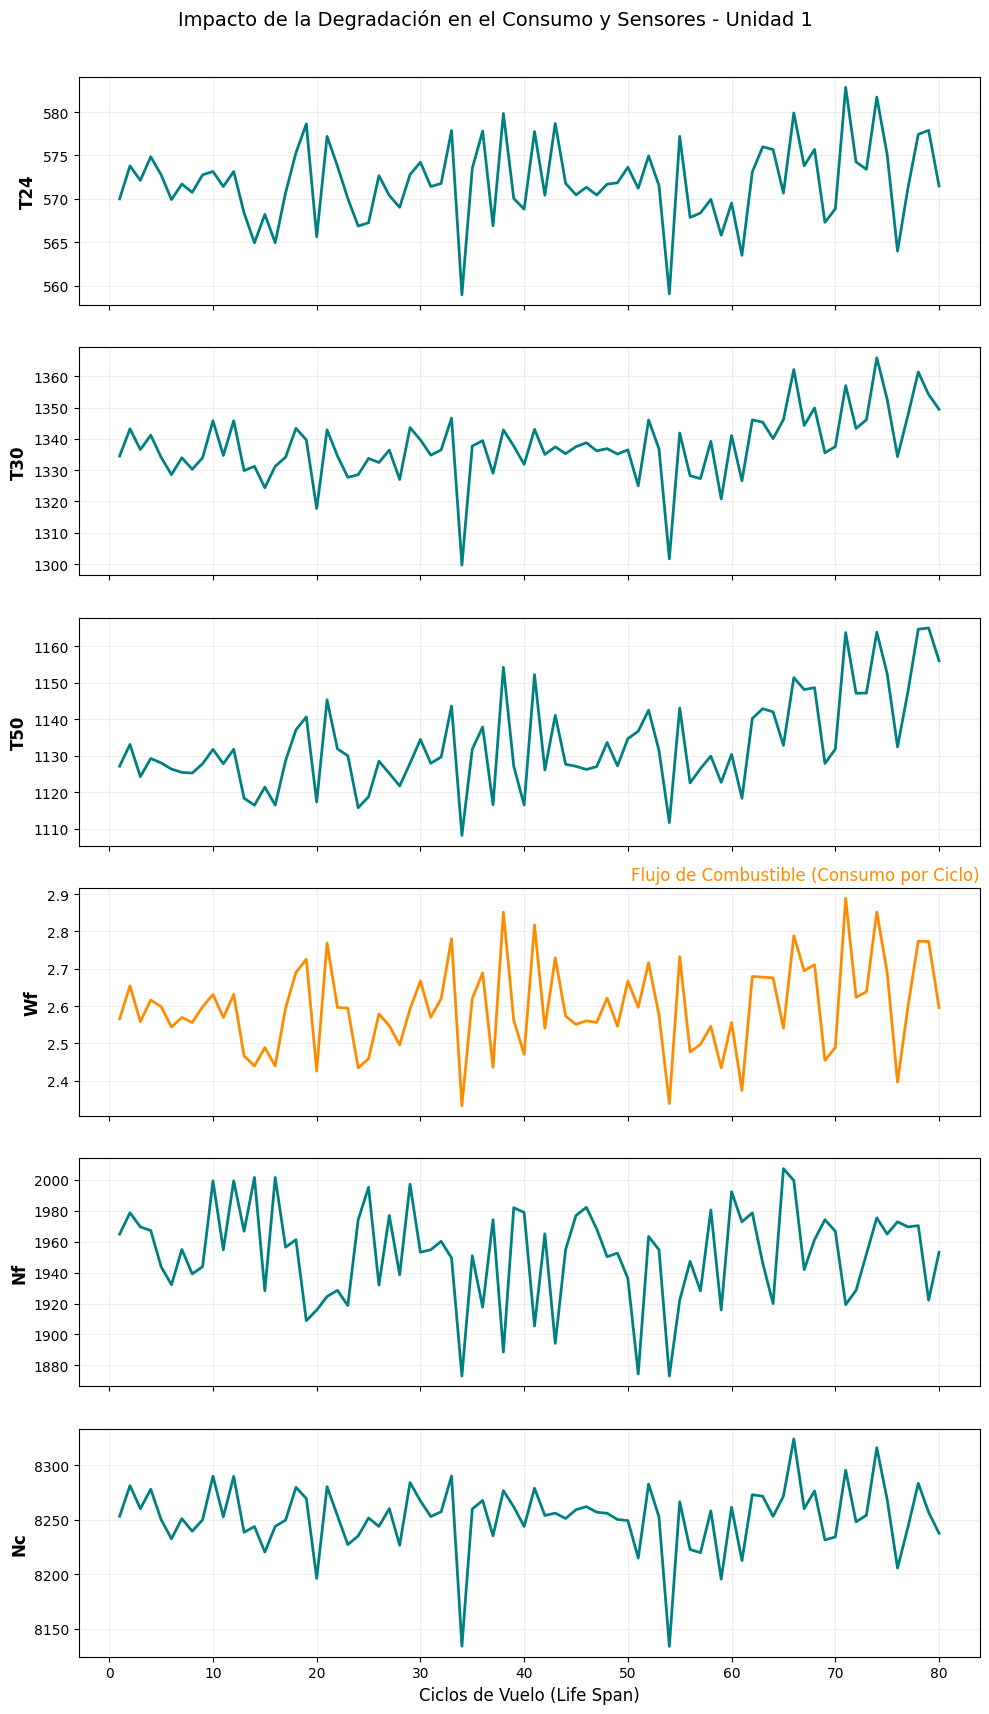

In [9]:
# Agregamos Wf a nuestra lista de deseos
sensores_interesantes = ['T24', 'T30', 'T50', 'P30', 'Wf', 'Nf', 'Nc']

with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Verificamos cuáles existen (Wf suele estar en la posición 10-12 aprox)
    sensores_validos = [s for s in sensores_interesantes if s in sensor_names]
    print(f"Sensores a graficar: {sensores_validos}")

    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    fig, axes = plt.subplots(len(sensores_validos), 1, figsize=(10, 3 * len(sensores_validos)), sharex=True)
    
    if len(sensores_validos) == 1: axes = [axes]

    for i, s_name in enumerate(sensores_validos):
        idx = np.where(sensor_names == s_name)[0][0]
        data_sensor = hdf.get('X_s_dev')[mask, idx]
        
        # Promediado por ciclo
        df_s = pd.DataFrame({'cycle': cycles, 'val': data_sensor})
        df_s_avg = df_s.groupby('cycle').mean()
        
        # Usamos un color naranja para Wf para destacarlo
        color = 'darkorange' if s_name == 'Wf' else 'teal'
        
        axes[i].plot(df_s_avg.index, df_s_avg['val'], color=color, linewidth=2)
        axes[i].set_ylabel(f"{s_name}", fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.2)
        
        if s_name == 'Wf':
            axes[i].set_title("Flujo de Combustible (Consumo por Ciclo)", loc='right', color='darkorange')

axes[-1].set_xlabel('Ciclos de Vuelo (Life Span)', fontsize=12)
plt.suptitle(f'Impacto de la Degradación en el Consumo y Sensores - Unidad {unit_id}', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

### ¿Qué está pasando?

1. El aumento de $T_{30}$ y $T_{50}$ 
    * $T_{30}$ (Temperatura de salida del HPC): Al caer la eficiencia del compresor ($\eta$), este se vuelve menos "hábil" para comprimir el aire. Para alcanzar la relación de presión necesaria, el proceso se vuelve más irreversible y genera más calor residual. Básicamente, el compresor está "luchando" más y eso calienta el aire por encima de lo normal.
    * $T_{50}$ (Temperatura de salida de la LPT / EGT): Es el síntoma más famoso. Como el motor es menos eficiente, el sistema de control (FADEC) tiene que quemar más combustible para mantener el empuje (thrust). Esto eleva la temperatura de los gases de escape. Un aumento en el "EGT Margin" es lo que las aerolíneas monitorean para decidir cuándo bajar un motor a mantenimiento.

2. El aumento de $W_f$ (Fuel Flow)

Este es el costo económico de la falla. Si el HPC no está fluyendo bien el aire o lo hace de forma ineficiente, necesitas inyectar más energía (queroseno) para compensar esa pérdida de rendimiento y lograr que la turbina genere la potencia necesaria para mover el fan. Es normal ver una tendencia ascendente clara en $W_f$ a medida que el motor envejece.3. El aumento de $N_c$ (Core Speed)A medida que el HPC se degrada y pierde capacidad de flujo ($\phi$), el eje de alta presión suele girar más rápido para intentar procesar la misma masa de aire que un motor limpio. Es un mecanismo de compensación del sistema de control.

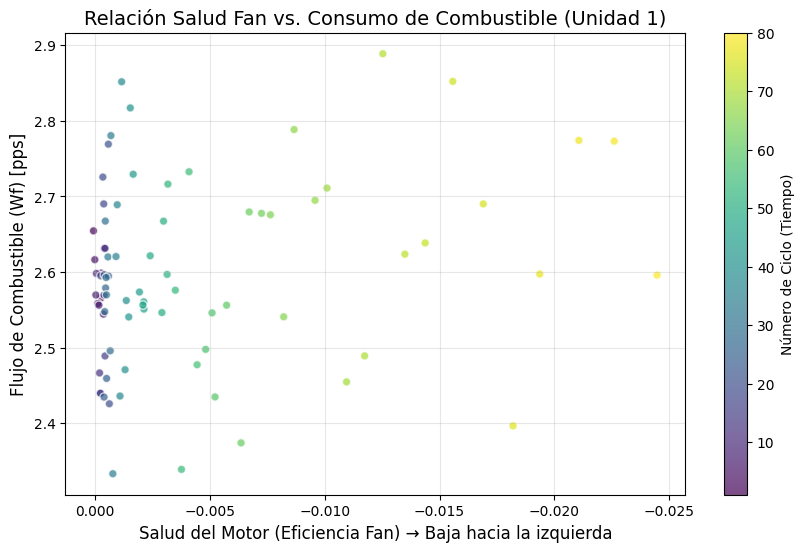

In [10]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Obtener nombres y localizar índices
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    # 2. Extraer datos
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    theta_hpt = hdf.get('T_dev')[mask, 4]  # Usamos la columna 0 para Fan
    wf_data = hdf.get('X_s_dev')[mask, wf_idx]

    # 3. Consolidar promedios por ciclo para evitar el ruido de cada segundo
    df_corr = pd.DataFrame({
        'cycle': cycles,
        'salud_hpt': theta_hpt,
        'combustible': wf_data
    })
    df_avg = df_corr.groupby('cycle').mean()

# 4. Graficar la Correlación
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_avg['salud_hpt'], df_avg['combustible'], 
                      c=df_avg.index, cmap='viridis', alpha=0.7, edgecolors='w')

# Añadir barra de color para ver el paso del tiempo (ciclos)
cbar = plt.colorbar(scatter)
cbar.set_label('Número de Ciclo (Tiempo)')

plt.title(f'Relación Salud Fan vs. Consumo de Combustible (Unidad {unit_id})', fontsize=14)
plt.xlabel('Salud del Motor (Eficiencia Fan) → Baja hacia la izquierda', fontsize=12)
plt.ylabel('Flujo de Combustible (Wf) [pps]', fontsize=12)
plt.grid(True, alpha=0.3)

# Invertir el eje X puede ayudar a visualizar el "avance" de la falla
plt.gca().invert_xaxis() 

plt.show()

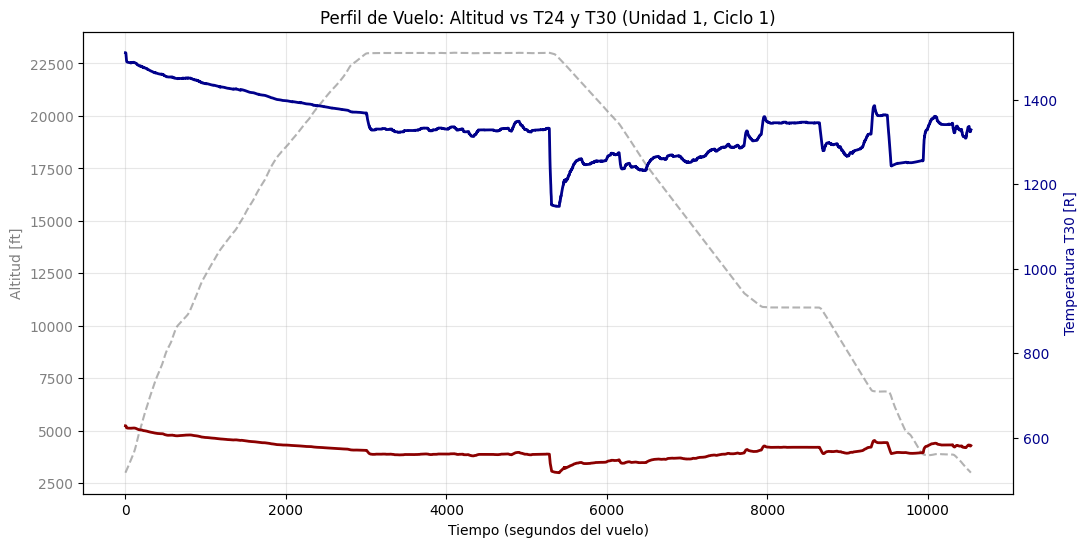

In [11]:
vuelo_id = 1 # Vamos a ver solo el primer vuelo

with h5py.File(file_path, 'r') as hdf:
    # 1. Localizar índices de Altitud (en W) y T48 (en X_s)
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    
    alt_idx = np.where(w_names == 'alt')[0][0]
    t24_idx = np.where(s_names == 'T24')[0][0]
    t30_idx = np.where(s_names == 'T30')[0][0]
    
    # 2. Extraer datos de la Unidad 1
    A_dev = hdf.get('A_dev')[:]
    # Máscara doble: Unidad 1 Y Ciclo 1
    mask_vuelo = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == vuelo_id)
    
    alt_data = hdf.get('W_dev')[mask_vuelo, alt_idx]
    t24_data = hdf.get('X_s_dev')[mask_vuelo, t24_idx]
    t30_data = hdf.get('X_s_dev')[mask_vuelo, t30_idx]
    
    # Creamos un eje de tiempo (puntos de datos)
    time_steps = np.arange(len(alt_data))

# 3. Graficar
fig, ax1 = plt.subplots(figsize=(12, 6))


# Altitud (Eje Izquierdo)
ax1.plot(time_steps, alt_data, color='gray', linestyle='--', alpha=0.6, label='Altitud')
ax1.set_xlabel('Tiempo (segundos del vuelo)')
ax1.set_ylabel('Altitud [ft]', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# T24 (Eje Derecho)
ax2 = ax1.twinx()
ax2.plot(time_steps, t24_data, color='darkred', linewidth=2, label='Temperatura T24')
ax2.set_ylabel('Temperatura T24 [R]', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

ax2.plot(time_steps, t30_data, color='darkblue', linewidth=2, label='Temperatura T30')
ax2.set_ylabel('Temperatura T30 [R]', color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title(f'Perfil de Vuelo: Altitud vs T24 y T30 (Unidad {unit_id}, Ciclo {vuelo_id})')
ax1.grid(True, alpha=0.3)
plt.show()

### Análisis del Perfil de $T_{30}$ (Temperatura de salida del HPC)

La forma de la curva azul ($T_{30}$) está dictada principalmente por dos factores: la altitud (línea gris) y el ajuste de potencia (Mach/Thrust).

1. Fase de Ascenso (0 a 3,000s):Notarás que a medida que la altitud aumenta, $T_{30}$ disminuye.
    
    ¿Por qué? Porque la temperatura del aire ambiente ($T_2$) baja drásticamente al subir. Aunque el motor está trabajando duro para subir, el aire que entra está tan frío que la temperatura final a la salida del compresor termina siendo menor que a nivel del suelo.

2. Fase de Crucero (3,000 a 5,500s):Aquí la altitud se estabiliza en unos 23,000 ft. La $T_{30}$ se vuelve relativamente plana, pero verás pequeñas oscilaciones. Esas son correcciones del sistema de control para mantener la velocidad (Mach) frente a cambios en la densidad del aire.

3. El "Salto" a los 5,300s:Ese bajón repentino en $T_{30}$ es muy característico. Probablemente representa una reducción deliberada de potencia o un cambio en el régimen de vuelo (descenso inicial o cambio de nivel). Al reducirse la carga sobre el motor, la compresión disminuye y la temperatura cae inmediatamente.

4. Fase de Descenso (5,500s en adelante):A medida que el avión baja, la temperatura ambiente sube y la presión atmosférica aumenta. Por eso ves que la tendencia general de $T_{30}$ es volver a subir, aunque con mucho ruido debido a que el piloto/piloto automático está ajustando los aceleradores para el aterrizaje.

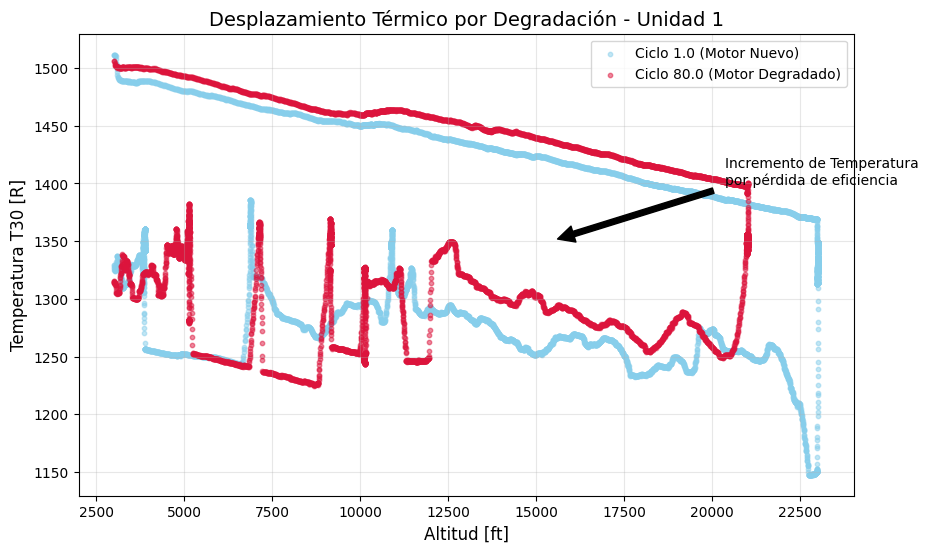

In [12]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Localizar índices
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    alt_idx = np.where(w_names == 'alt')[0][0]
    t30_idx = np.where(s_names == 'T30')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos_disponibles = np.unique(A_dev[u_mask, 1])
    
    ciclo_joven = vuelos_disponibles[0]  # Ciclo 1
    ciclo_viejo = vuelos_disponibles[-1] # Último ciclo antes de falla
    
    # 2. Extraer datos para ambos ciclos
    def get_vuelo_data(c_id):
        mask = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == c_id)
        return hdf.get('W_dev')[mask, alt_idx], hdf.get('X_s_dev')[mask, t30_idx]

    alt_joven, t30_joven = get_vuelo_data(ciclo_joven)
    alt_viejo, t30_viejo = get_vuelo_data(ciclo_viejo)

# 3. Graficar
plt.figure(figsize=(10, 6))

# Usamos scatter porque los puntos no están necesariamente en orden de altitud
plt.scatter(alt_joven, t30_joven, color='skyblue', alpha=0.5, s=10, label=f'Ciclo {ciclo_joven} (Motor Nuevo)')
plt.scatter(alt_viejo, t30_viejo, color='crimson', alpha=0.5, s=10, label=f'Ciclo {ciclo_viejo} (Motor Degradado)')

plt.title(f'Desplazamiento Térmico por Degradación - Unidad {unit_id}', fontsize=14)
plt.xlabel('Altitud [ft]', fontsize=12)
plt.ylabel('Temperatura T30 [R]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Añadir una flecha que indique el desplazamiento
plt.annotate('Incremento de Temperatura\npor pérdida de eficiencia', 
             xy=(alt_joven.mean(), t30_viejo.mean()), 
             xytext=(alt_joven.mean() + 5000, t30_viejo.mean() + 50),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

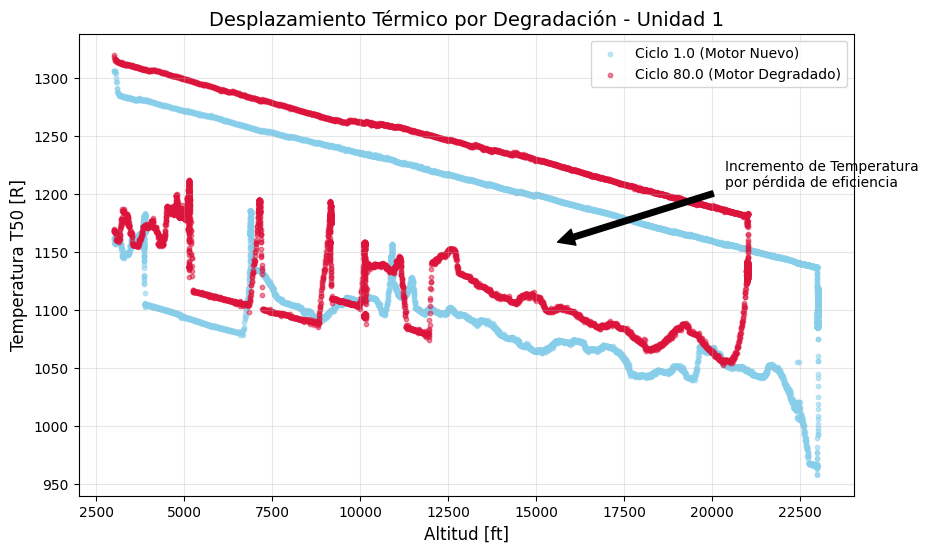

In [18]:
with h5py.File(file_path, 'r') as hdf:
    # 1. Localizar índices
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    alt_idx = np.where(w_names == 'alt')[0][0]
    t50_idx = np.where(s_names == 'T50')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos_disponibles = np.unique(A_dev[u_mask, 1])
    
    ciclo_joven = vuelos_disponibles[0]  # Ciclo 1
    ciclo_viejo = vuelos_disponibles[-1] # Último ciclo antes de falla
    
    # 2. Extraer datos para ambos ciclos
    def get_vuelo_data(c_id):
        mask = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == c_id)
        return hdf.get('W_dev')[mask, alt_idx], hdf.get('X_s_dev')[mask, t50_idx]

    alt_joven, t50_joven = get_vuelo_data(ciclo_joven)
    alt_viejo, t50_viejo = get_vuelo_data(ciclo_viejo)

# 3. Graficar
plt.figure(figsize=(10, 6))

# Usamos scatter porque los puntos no están necesariamente en orden de altitud
plt.scatter(alt_joven, t50_joven, color='skyblue', alpha=0.5, s=10, label=f'Ciclo {ciclo_joven} (Motor Nuevo)')
plt.scatter(alt_viejo, t50_viejo, color='crimson', alpha=0.5, s=10, label=f'Ciclo {ciclo_viejo} (Motor Degradado)')

plt.title(f'Desplazamiento Térmico por Degradación - Unidad {unit_id}', fontsize=14)
plt.xlabel('Altitud [ft]', fontsize=12)
plt.ylabel('Temperatura T50 [R]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Añadir una flecha que indique el desplazamiento
plt.annotate('Incremento de Temperatura\npor pérdida de eficiencia', 
             xy=(alt_joven.mean(), t50_viejo.mean()), 
             xytext=(alt_joven.mean() + 5000, t50_viejo.mean() + 50),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

<div class="alert alert-block alert-success">
Efectivamente, T30 y T50 presentan un incremento de temperatura en el último ciclo de operación con respecto al primer ciclo. Esto es consistente con la teoría de que, a medida que el motor se degrada, su eficiencia disminuye, lo que resulta en un aumento de las temperaturas de los gases de escape (T30 y T50) para mantener el mismo nivel de rendimiento. Este aumento térmico es un indicador clave de la degradación del motor y es crucial para el monitoreo de la salud del sistema.

Presiones encontradas: [np.str_('P15'), np.str_('P2'), np.str_('P21'), np.str_('P24'), np.str_('Ps30'), np.str_('P40'), np.str_('P50')]


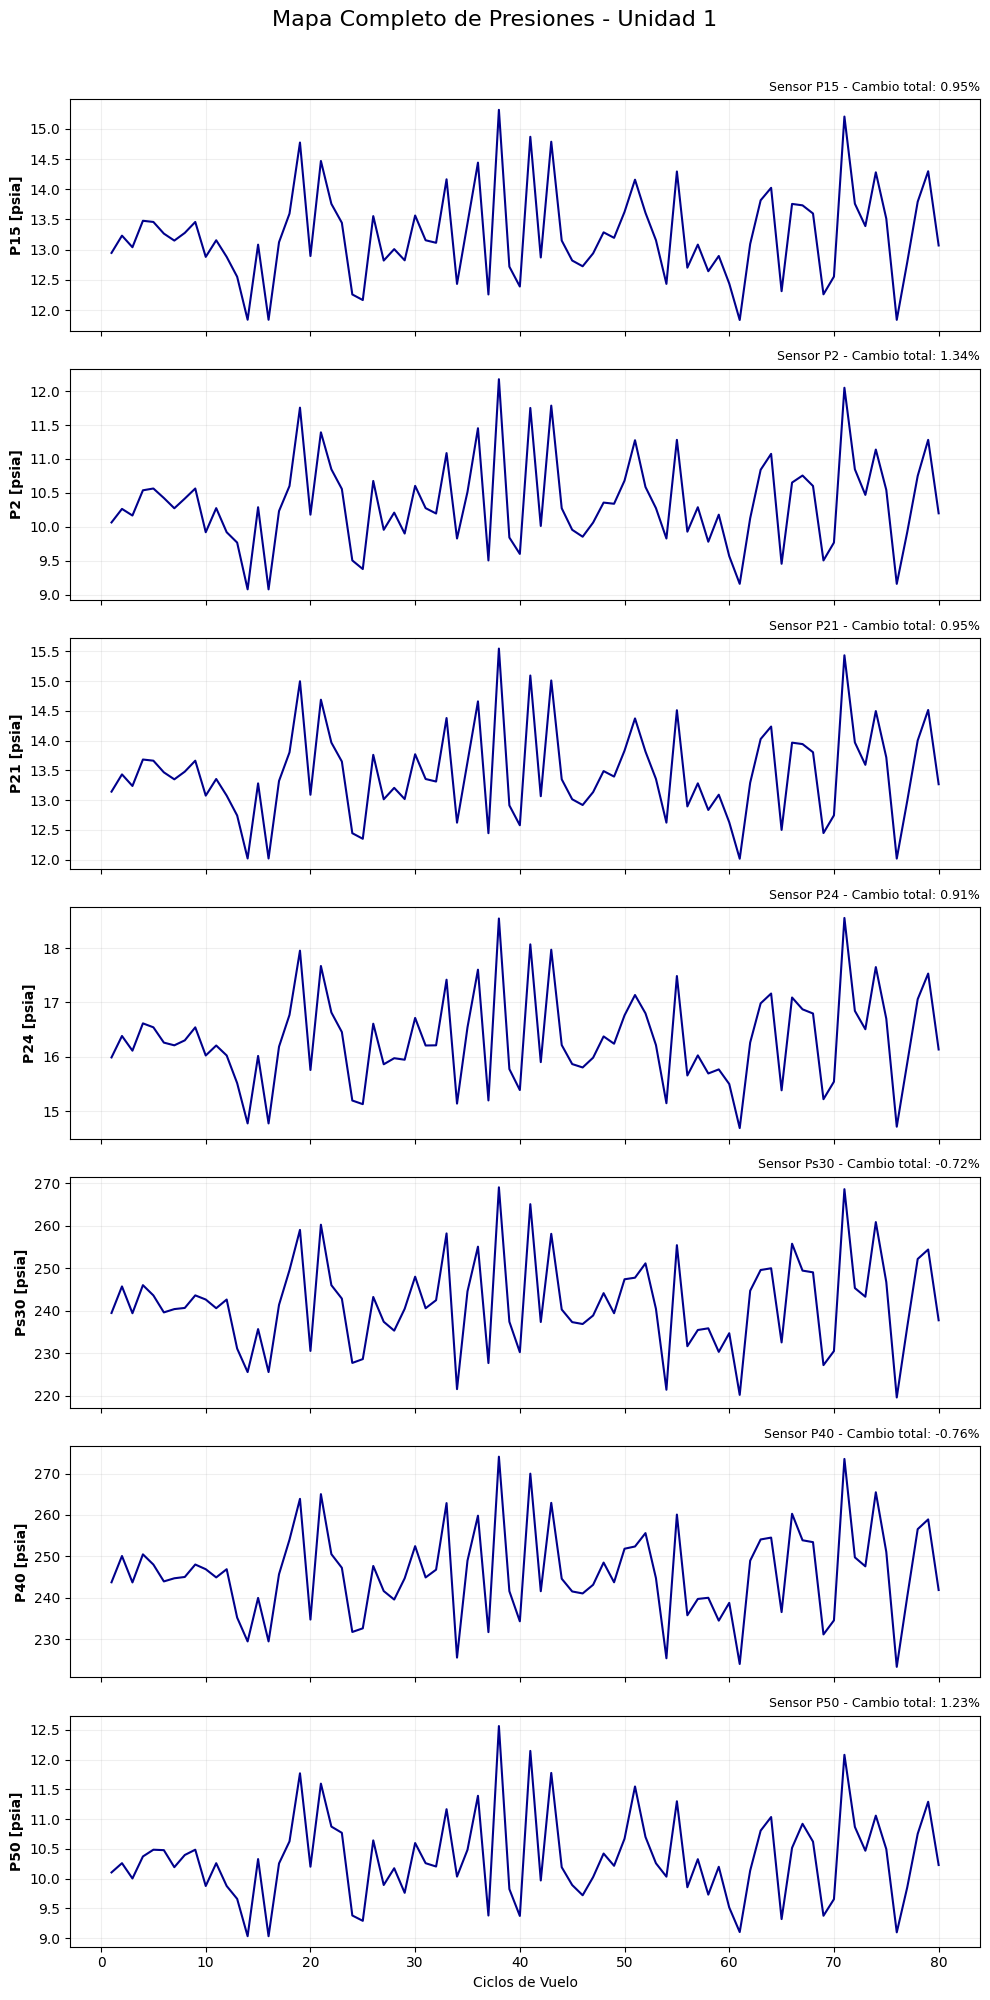

In [19]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Identificamos todos los sensores que empiezan con 'P'
    presiones_disponibles = [s for s in sensor_names if s.startswith('P')]
    print(f"Presiones encontradas: {presiones_disponibles}")
    
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]

    # Configuramos una cuadrícula de subplots
    n_p = len(presiones_disponibles)
    fig, axes = plt.subplots(n_p, 1, figsize=(10, 3 * n_p), sharex=True)
    
    # Aseguramos que axes sea una lista si solo hay una presión
    if n_p == 1: axes = [axes]

    for i, p_name in enumerate(presiones_disponibles):
        idx = np.where(sensor_names == p_name)[0][0]
        data_raw = hdf.get('X_s_dev')[mask, idx]
        
        # Promedio por ciclo para ver la tendencia limpia
        df_tmp = pd.DataFrame({'cycle': cycles, 'val': data_raw})
        df_avg = df_tmp.groupby('cycle').mean()
        
        axes[i].plot(df_avg.index, df_avg['val'], color='darkblue', linewidth=1.5)
        axes[i].set_ylabel(f"{p_name} [psia]", fontweight='bold')
        axes[i].grid(True, alpha=0.2)
        
        # Calcular el cambio porcentual total para ver qué tanto varió
        delta = ((df_avg['val'].iloc[-1] - df_avg['val'].iloc[0]) / df_avg['val'].iloc[0]) * 100
        axes[i].set_title(f"Sensor {p_name} - Cambio total: {delta:.2f}%", loc='right', fontsize=9)

axes[-1].set_xlabel('Ciclos de Vuelo')
plt.suptitle(f'Mapa Completo de Presiones - Unidad {unit_id}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

### ¿Por qué bajan $P_{s30}$ y $P_{40}$?

Estas dos presiones están situadas justo después del "culpable" (el HPC).

* $P_{s30}$ (Presión Estática a la salida del HPC): Es el sensor crítico para medir la salud del compresor de alta. Al haber una falla de flujo ($\phi$) o eficiencia ($\eta$), las aspas del compresor ya no pueden "empujar" o comprimir el aire con la misma efectividad. Aunque el eje gire más rápido (como viste con el aumento de $N_c$), el compresor se vuelve aerodinámicamente menos capaz, lo que resulta en una caída de la presión de entrega.
* $P_{40}$ (Presión a la salida de la cámara de combustión): Como $P_{40}$ depende directamente de cuánta presión le entregue el HPC ($P_{30}$), si el HPC falla, la presión en la entrada de la turbina de alta también cae inevitablemente.

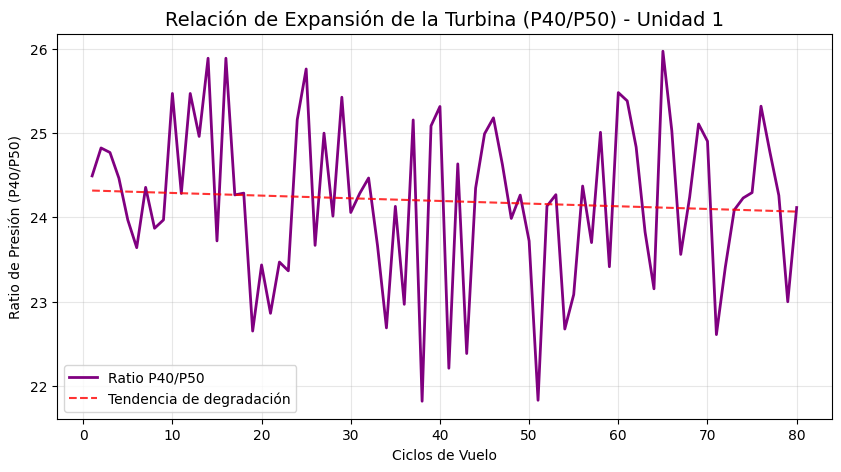

Ratio inicial: 24.4913
Ratio final: 24.1166


In [20]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Verificamos si P40 y P50 existen en el dataset
    if 'P40' in sensor_names and 'P50' in sensor_names:
        idx_p40 = np.where(sensor_names == 'P40')[0][0]
        idx_p50 = np.where(sensor_names == 'P50')[0][0]
        
        A_dev = hdf.get('A_dev')[:]
        mask = A_dev[:, 0] == unit_id
        cycles = A_dev[mask, 1]
        
        # Extraemos datos
        p40_data = hdf.get('X_s_dev')[mask, idx_p40]
        p50_data = hdf.get('X_s_dev')[mask, idx_p50]
        
        # Creamos el DataFrame para promediar por ciclo
        df_ratio = pd.DataFrame({
            'cycle': cycles,
            'ratio': p40_data / p50_data
        })
        df_avg = df_ratio.groupby('cycle').mean()
        
        # Graficamos
        plt.figure(figsize=(10, 5))
        plt.plot(df_avg.index, df_avg['ratio'], color='purple', linewidth=2, label='Ratio P40/P50')
        
        # Añadir línea de tendencia
        z = np.polyfit(df_avg.index, df_avg['ratio'], 1)
        p = np.poly1d(z)
        plt.plot(df_avg.index, p(df_avg.index), "r--", alpha=0.8, label='Tendencia de degradación')
        
        plt.title(f'Relación de Expansión de la Turbina (P40/P50) - Unidad {unit_id}', fontsize=14)
        plt.xlabel('Ciclos de Vuelo')
        plt.ylabel('Ratio de Presión (P40/P50)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"Ratio inicial: {df_avg['ratio'].iloc[0]:.4f}")
        print(f"Ratio final: {df_avg['ratio'].iloc[-1]:.4f}")
    else:
        print("Lo siento, P40 o P50 no están disponibles en este dataset (DS01).")
        print(f"Sensores disponibles: {[s for s in sensor_names if s.startswith('P')]}")

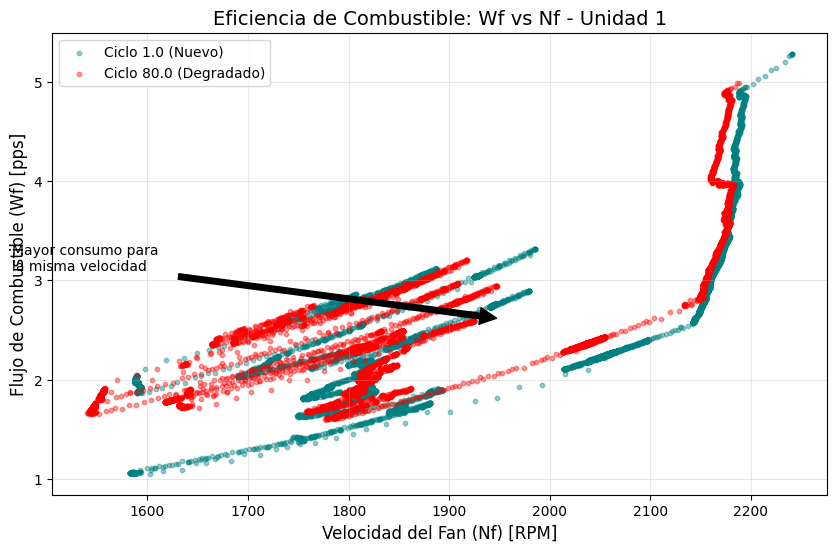

In [21]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # 1. Localizar índices de Nf (Fan Speed) y Wf (Fuel Flow)
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos = np.unique(A_dev[u_mask, 1])
    
    ciclo_ini = vuelos[0]
    ciclo_fin = vuelos[-1]
    
    # 2. Extraer datos (Unidad 1, Ciclos primero y último)
    mask_ini = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == ciclo_ini)
    mask_fin = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == ciclo_fin)
    
    nf_ini, wf_ini = hdf.get('X_s_dev')[mask_ini, nf_idx], hdf.get('X_s_dev')[mask_ini, wf_idx]
    nf_fin, wf_fin = hdf.get('X_s_dev')[mask_fin, nf_idx], hdf.get('X_s_dev')[mask_fin, wf_idx]

# 3. Graficar la relación
plt.figure(figsize=(10, 6))

plt.scatter(nf_ini, wf_ini, color='teal', alpha=0.4, s=10, label=f'Ciclo {ciclo_ini} (Nuevo)')
plt.scatter(nf_fin, wf_fin, color='red', alpha=0.4, s=10, label=f'Ciclo {ciclo_fin} (Degradado)')

plt.title(f'Eficiencia de Combustible: Wf vs Nf - Unidad {unit_id}', fontsize=14)
plt.xlabel('Velocidad del Fan (Nf) [RPM]', fontsize=12)
plt.ylabel('Flujo de Combustible (Wf) [pps]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Dibujar una flecha para mostrar el "Fuel Penalty"
plt.annotate('Mayor consumo para\nla misma velocidad', 
             xy=(nf_ini.mean(), wf_fin.mean()), 
             xytext=(nf_ini.mean() - 500, wf_fin.mean() + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

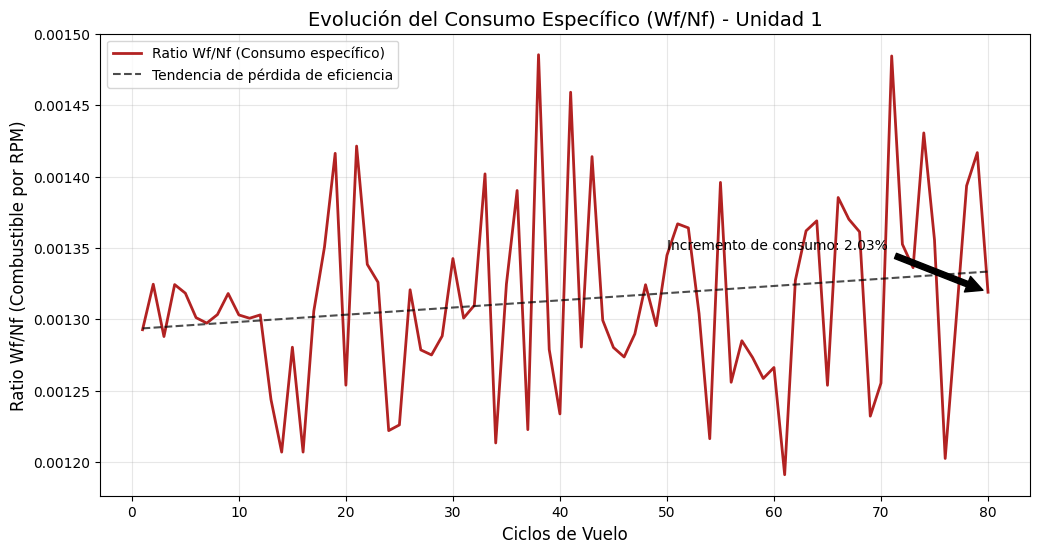

In [22]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # 1. Localizar índices
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    # 2. Extraer datos y calcular el ratio segundo a segundo
    nf_data = hdf.get('X_s_dev')[mask, nf_idx]
    wf_data = hdf.get('X_s_dev')[mask, wf_idx]
    
    # Creamos el ratio
    ratio_data = wf_data / nf_data
    
    # 3. Consolidar por ciclo para eliminar el ruido transitorio
    df_ratio = pd.DataFrame({'cycle': cycles, 'ratio': ratio_data})
    df_avg = df_ratio.groupby('cycle').mean()

# 4. Graficar la evolución
plt.figure(figsize=(12, 6))
plt.plot(df_avg.index, df_avg['ratio'], color='firebrick', linewidth=2, label='Ratio Wf/Nf (Consumo específico)')

# Añadir una línea de tendencia para ver la pendiente de degradación
z = np.polyfit(df_avg.index, df_avg['ratio'], 1)
p = np.poly1d(z)
plt.plot(df_avg.index, p(df_avg.index), "k--", alpha=0.7, label='Tendencia de pérdida de eficiencia')

plt.title(f'Evolución del Consumo Específico (Wf/Nf) - Unidad {unit_id}', fontsize=14)
plt.xlabel('Ciclos de Vuelo', fontsize=12)
plt.ylabel('Ratio Wf/Nf (Combustible por RPM)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Anotación del incremento porcentual
inc_perc = ((df_avg['ratio'].iloc[-1] - df_avg['ratio'].iloc[0]) / df_avg['ratio'].iloc[0]) * 100
plt.annotate(f'Incremento de consumo: {inc_perc:.2f}%', 
             xy=(df_avg.index[-1], df_avg['ratio'].iloc[-1]),
             xytext=(df_avg.index[-1]-30, df_avg['ratio'].iloc[-1] + (df_avg['ratio'].max()*0.02)),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

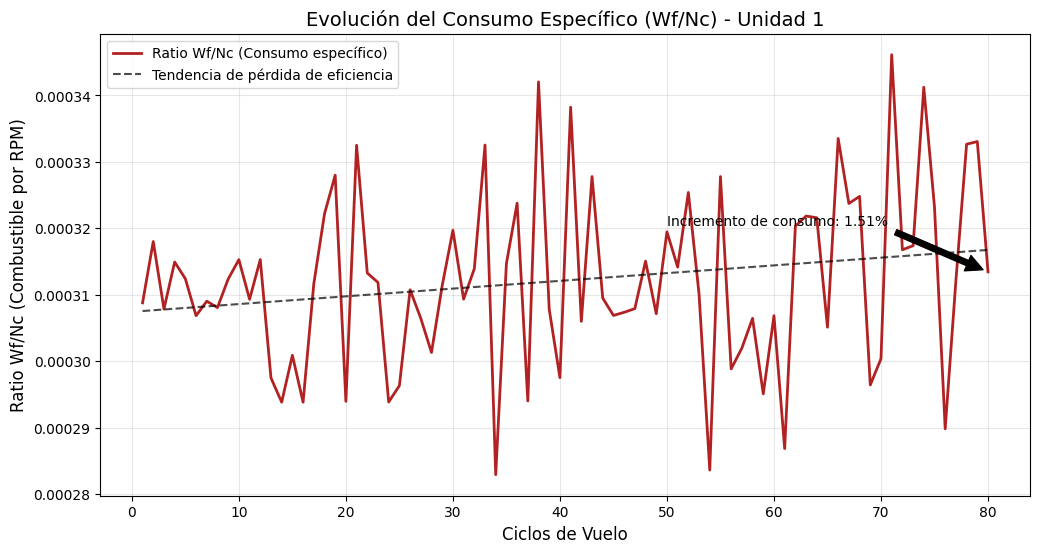

In [13]:
with h5py.File(file_path, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # 1. Localizar índices
    nc_idx = np.where(sensor_names == 'Nc')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    # 2. Extraer datos y calcular el ratio segundo a segundo
    nc_data = hdf.get('X_s_dev')[mask, nc_idx]
    wf_data = hdf.get('X_s_dev')[mask, wf_idx]
    
    # Creamos el ratio
    ratio_data = wf_data / nc_data
    
    # 3. Consolidar por ciclo para eliminar el ruido transitorio
    df_ratio = pd.DataFrame({'cycle': cycles, 'ratio': ratio_data})
    df_avg = df_ratio.groupby('cycle').mean()

# 4. Graficar la evolución
plt.figure(figsize=(12, 6))
plt.plot(df_avg.index, df_avg['ratio'], color='firebrick', linewidth=2, label='Ratio Wf/Nc (Consumo específico)')

# Añadir una línea de tendencia para ver la pendiente de degradación
z = np.polyfit(df_avg.index, df_avg['ratio'], 1)
p = np.poly1d(z)
plt.plot(df_avg.index, p(df_avg.index), "k--", alpha=0.7, label='Tendencia de pérdida de eficiencia')

plt.title(f'Evolución del Consumo Específico (Wf/Nc) - Unidad {unit_id}', fontsize=14)
plt.xlabel('Ciclos de Vuelo', fontsize=12)
plt.ylabel('Ratio Wf/Nc (Combustible por RPM)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Anotación del incremento porcentual
inc_perc = ((df_avg['ratio'].iloc[-1] - df_avg['ratio'].iloc[0]) / df_avg['ratio'].iloc[0]) * 100
plt.annotate(f'Incremento de consumo: {inc_perc:.2f}%', 
             xy=(df_avg.index[-1], df_avg['ratio'].iloc[-1]),
             xytext=(df_avg.index[-1]-30, df_avg['ratio'].iloc[-1] + (df_avg['ratio'].max()*0.02)),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()